In [1]:
!python --version

Python 3.10.4


In [2]:
%pip install -q matplotlib nest-asyncio openai pandas python-dotenv safetensors scikit-learn torch tiktoken tqdm 

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

In [111]:
import sqlite3
conn = sqlite3.connect(f'../train_embeddings.db')

In [112]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM comments_gpt4_annotated")
gpt_4_annotated_comments = cursor.fetchall()

# sort by first column
gpt_4_annotated_comments.sort(key=lambda x: x[0])

In [113]:
# get ids from gpt_4_annotated_comments

ids = []
for comment in gpt_4_annotated_comments:
    ids.append(comment[0])

len(ids)

5637

In [115]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM comments WHERE id IN (%s)" % ','.join('?'*len(ids)), ids)
human_annotated_comments = cursor.fetchall()

human_annotated_comments.sort(key=lambda x: x[0])
len(human_annotated_comments)

5637

In [138]:
length_to_match = []

length_to_toxic_match = []
length_to_severe_toxic_match = []
length_to_obscene_match = []
length_to_threat_match = []
length_to_insult_match = []
length_to_identity_hate_match = []

matches_human = 0

toxic = (0, 0)
severe_toxic = (0, 0)
obscene = (0, 0)
threat = (0, 0)
insult = (0, 0)
identity_hate = (0, 0)

for i in range(0, len(ids)):
    comment_text = human_annotated_comments[i][1]
    ai_annotation = gpt_4_annotated_comments[i][2: 8]
    human_annotation = human_annotated_comments[i][2: 8]    

    # log each time the AI and human flag a comment under each category    
    toxic = (toxic[0] + (1 if ai_annotation[0] == 1 else 0), toxic[1] + (1 if human_annotation[0] == 1 else 0))
    severe_toxic = (severe_toxic[0] + (1 if ai_annotation[1] == 1 else 0), severe_toxic[1] + (1 if human_annotation[1] == 1 else 0))
    obscene = (obscene[0] + (1 if ai_annotation[2] == 1 else 0), obscene[1] + (1 if human_annotation[2] == 1 else 0))
    threat = (threat[0] + (1 if ai_annotation[3] == 1 else 0), threat[1] + (1 if human_annotation[3] == 1 else 0))
    insult = (insult[0] + (1 if ai_annotation[4] == 1 else 0), insult[1] + (1 if human_annotation[4] == 1 else 0))
    identity_hate = (identity_hate[0] + (1 if ai_annotation[5] == 1 else 0), identity_hate[1] + (1 if human_annotation[5] == 1 else 0))

    # if the AI and human agree on a comment, log it
    human_ai_match = ai_annotation == human_annotation
    if human_ai_match:
        matches_human += 1

    length_to_match.append((len(comment_text), human_ai_match))
    length_to_toxic_match.append((len(comment_text), human_annotation[0] == ai_annotation[0]))
    length_to_severe_toxic_match.append((len(comment_text), human_annotation[1] == ai_annotation[1]))
    length_to_obscene_match.append((len(comment_text), human_annotation[2] == ai_annotation[2]))
    length_to_threat_match.append((len(comment_text), human_annotation[3] == ai_annotation[3]))
    length_to_insult_match.append((len(comment_text), human_annotation[4] == ai_annotation[4]))
    length_to_identity_hate_match.append((len(comment_text), human_annotation[5] == ai_annotation[5]))
    



In [142]:
lengths = 0
max_length = 0
min_length = 10000

trues = 0

for l in length_to_match:
    if l[1] == True:
        trues += 1

    lengths += l[0]
    if l[0] > max_length:
        max_length = l[0]

    if l[0] < min_length:
        min_length = l[0]
    
    
print("Max length: ", max_length)
print("Min length: ", min_length)
print("Average length: ", lengths / len(length_to_match))
print("% Agrees: ", trues / len(length_to_match))

Max length:  5000
Min length:  14
Average length:  401.3377683164804
% Agrees:  0.7709774702856129


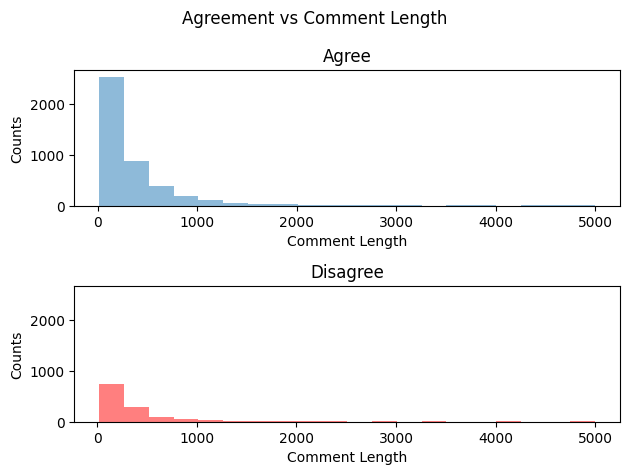

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_match if i[1]]
disagree = [i[0] for i in length_to_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Agreement vs Comment Length')
plt.tight_layout()
plt.show()

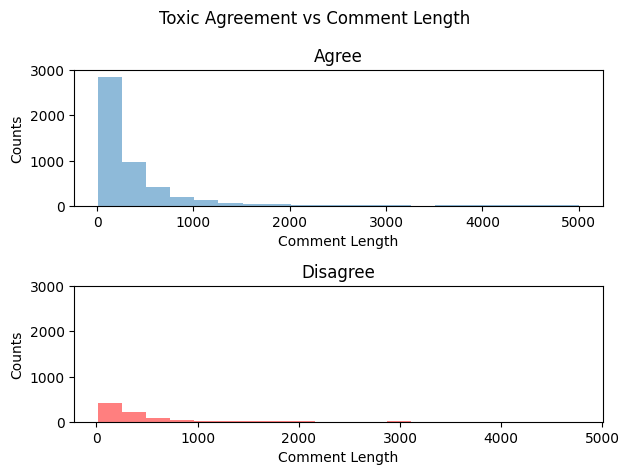

In [137]:
import matplotlib.pyplot as plt
import numpy as np

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_toxic_match if i[1]]
disagree = [i[0] for i in length_to_toxic_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Toxic Agreement vs Comment Length')
plt.tight_layout()
plt.show()

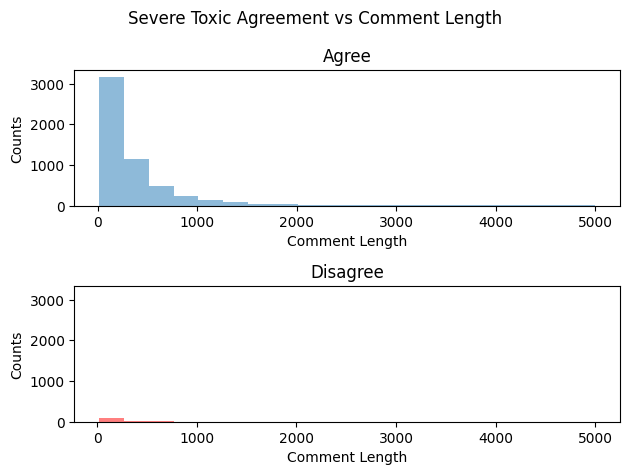

In [130]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_severe_toxic_match if i[1]]
disagree = [i[0] for i in length_to_severe_toxic_match if not i[1]]


fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Severe Toxic Agreement vs Comment Length')
plt.tight_layout()
plt.show()

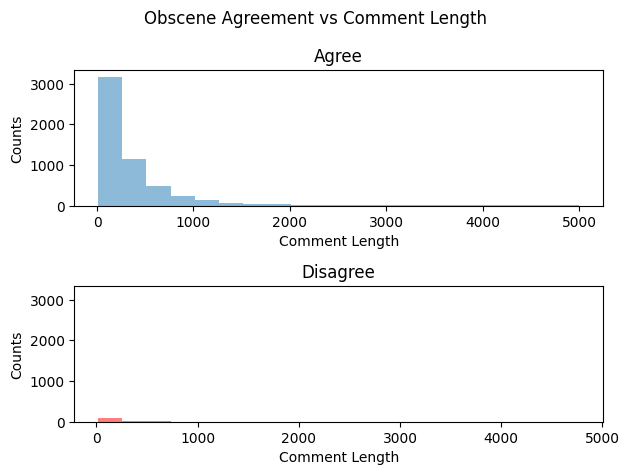

In [131]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_obscene_match if i[1]]
disagree = [i[0] for i in length_to_obscene_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Obscene Agreement vs Comment Length')
plt.tight_layout()
plt.show()

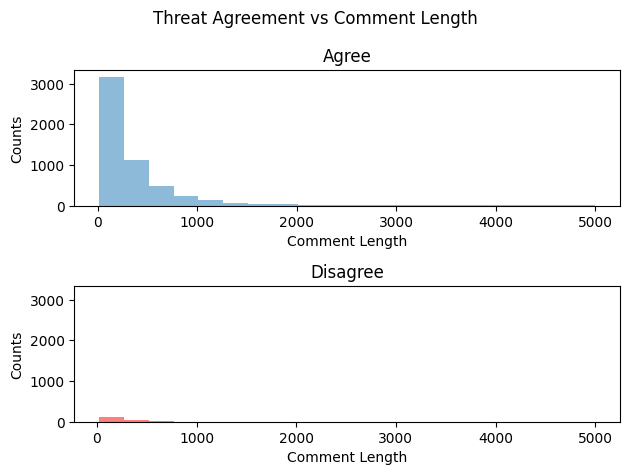

In [139]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_threat_match if i[1]]
disagree = [i[0] for i in length_to_threat_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Threat Agreement vs Comment Length')
plt.tight_layout()
plt.show()

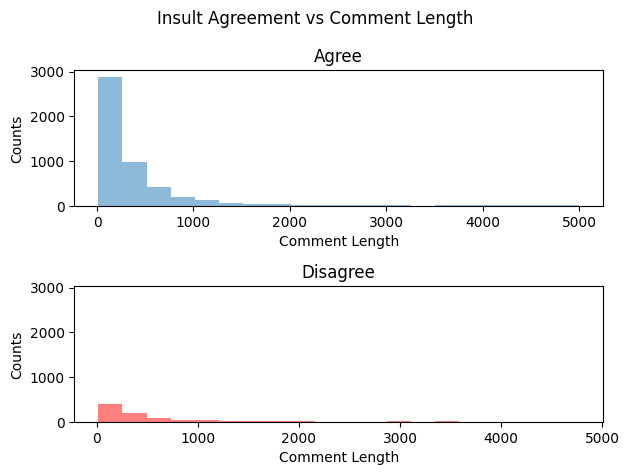

In [141]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_insult_match if i[1]]
disagree = [i[0] for i in length_to_insult_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Insult Agreement vs Comment Length')
plt.tight_layout()
plt.show()

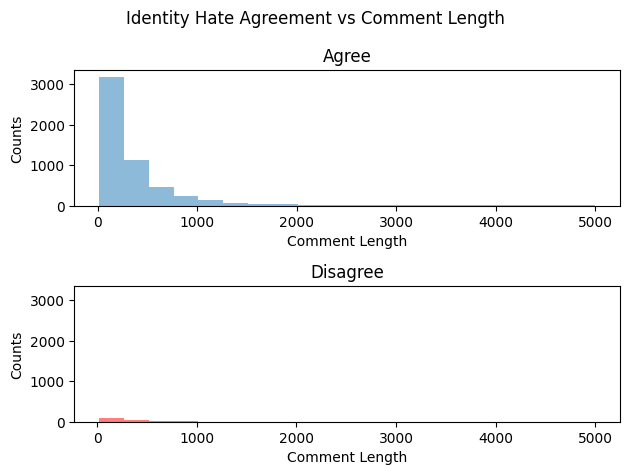

In [140]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# separate data into two lists based on agree or not agree
agree = [i[0] for i in length_to_identity_hate_match if i[1]]
disagree = [i[0] for i in length_to_identity_hate_match if not i[1]]

fig, axs = plt.subplots(2, sharey=True, tight_layout=True)

# create separate histograms 
axs[0].hist(agree, bins=20, alpha=0.5)
axs[0].set_title('Agree')
axs[0].set_xlabel('Comment Length')
axs[0].set_ylabel('Counts')

axs[1].hist(disagree, bins=20, alpha=0.5, color='r')
axs[1].set_title('Disagree')
axs[1].set_xlabel('Comment Length')
axs[1].set_ylabel('Counts')

fig.suptitle('Identity Hate Agreement vs Comment Length')
plt.tight_layout()
plt.show()

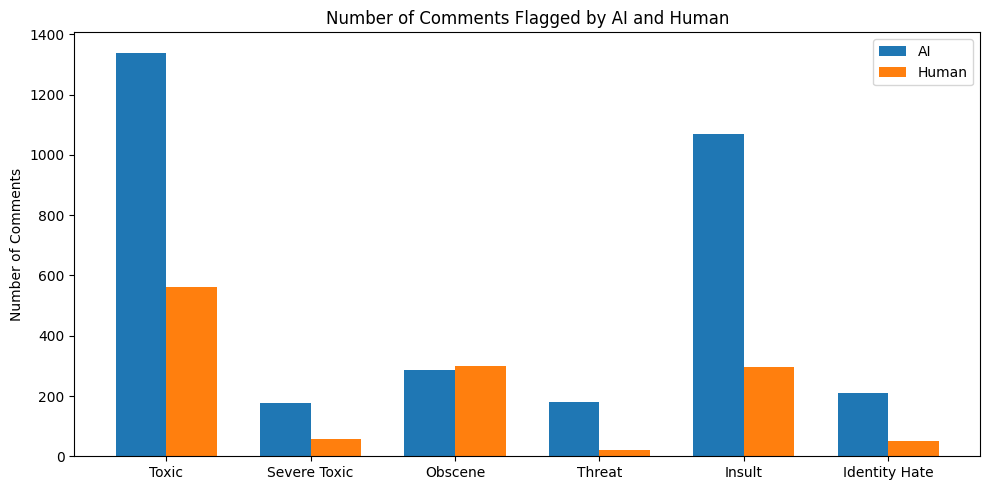

In [132]:

import matplotlib.pyplot as plt
import numpy as np

# Plot the number of times the AI and human agree on a comment under each category
labels = ['Toxic', 'Severe Toxic', 'Obscene', 'Threat', 'Insult', 'Identity Hate']
ai = [toxic[0], severe_toxic[0], obscene[0], threat[0], insult[0], identity_hate[0]]
human = [toxic[1], severe_toxic[1], obscene[1], threat[1], insult[1], identity_hate[1]]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, ai, width, label='AI')
rects2 = ax.bar(x + width/2, human, width, label='Human')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Comments')
ax.set_title('Number of Comments Flagged by AI and Human')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()

plt.show()